In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import joblib
from lightgbm import early_stopping, log_evaluation

In [6]:
demand  = pd.read_csv(r"C:\Users\ayesh\OneDrive\Documents\dynamic_pricing_engine\data\comprehensive data\demand.csv",  parse_dates=['timestamp'])
supply  = pd.read_csv(r"C:\Users\ayesh\OneDrive\Documents\dynamic_pricing_engine\data\comprehensive data\supply.csv",  parse_dates=['timestamp'])
pricing = pd.read_csv(r"C:\Users\ayesh\OneDrive\Documents\dynamic_pricing_engine\data\comprehensive data\pricing.csv", parse_dates=['timestamp'])
events  = pd.read_csv(r"C:\Users\ayesh\OneDrive\Documents\dynamic_pricing_engine\data\comprehensive data\events.csv", parse_dates=['date'])
print(demand.shape, supply.shape, pricing.shape, events.shape)

(8737, 23) (8737, 12) (8737, 12) (18, 6)


In [7]:
for name, df in [('demand', demand), ('supply', supply), ('pricing', pricing)]:
    print(f"\n── {name} ──")
    print(df.dtypes)
    print(df.isnull().sum()[df.isnull().sum() > 0])
    print(df.describe().round(2))


── demand ──
timestamp                datetime64[us]
hour                              int64
day_of_week                       int64
month                             int64
week                              int64
is_weekend                         bool
is_event                          int64
event_name                          str
event_type                          str
intraday_mult                   float64
dow_mult                        float64
seasonal_mult                   float64
event_demand_boost              float64
demand                            int64
demand_price_adjusted             int64
demand_lag_1h                   float64
demand_lag_3h                   float64
demand_lag_24h                  float64
demand_lag_7d                   float64
demand_rolling_3h               float64
demand_rolling_6h               float64
demand_rolling_24h              float64
demand_rolling_std_3h           float64
dtype: object
event_name               8524
event_type            

In [8]:
# ─────────────────────────────────────────────────────────────
# PRE-SECTION B PREP — run this cell right after loading CSVs
# ─────────────────────────────────────────────────────────────
# Assumes these DataFrames are already loaded:
#   demand, supply, pricing, events

# ── ACTION 2 ─────────────────────────────────────────────────
# Create event-type binary flags from the events calendar
# Do NOT use event_name or event_type as raw features —
# too sparse and high cardinality. Use binary flags instead.

weather_event_dates = set(
    events[events['event_type'] == 'weather']['date'].astype(str)
)
concert_event_dates = set(
    events[events['event_type'].isin(['concert', 'sports'])]['date'].astype(str)
)
festival_event_dates = set(
    events[events['event_type'].isin(['festival', 'holiday'])]['date'].astype(str)
)

demand['date_str'] = demand['timestamp'].dt.date.astype(str)

demand['is_weather_event']  = demand['date_str'].isin(weather_event_dates).astype(int)
demand['is_concert_event']  = demand['date_str'].isin(concert_event_dates).astype(int)
demand['is_festival_event'] = demand['date_str'].isin(festival_event_dates).astype(int)

demand.drop(columns=['date_str'], inplace=True)

# Quick check
print("── Action 2: Event type flags ──")
print(f"  is_weather_event  : {demand['is_weather_event'].sum()} event hours")
print(f"  is_concert_event  : {demand['is_concert_event'].sum()} event hours")
print(f"  is_festival_event : {demand['is_festival_event'].sum()} event hours")
print(f"  is_event (total)  : {demand['is_event'].sum()} event hours")
print()


# ── ACTION 5 ─────────────────────────────────────────────────
# Fix demand_rolling_std_3h — fill NaNs with 0, add +0.01 floor
# Prevents issues in correlation charts and log-scaled contexts

demand['demand_rolling_std_3h'] = (
    demand['demand_rolling_std_3h']
    .fillna(0)
    + 0.01
)

print("── Action 5: Rolling std fix ──")
print(f"  NaNs remaining : {demand['demand_rolling_std_3h'].isnull().sum()}")
print(f"  Min value      : {demand['demand_rolling_std_3h'].min():.3f}  (should be 0.01)")
print(f"  Max value      : {demand['demand_rolling_std_3h'].max():.2f}")
print()


# ── ACTION 3 ─────────────────────────────────────────────────
# Clearly name your two targets so you never mix them up
# downstream in Phase 2 and Phase 3

FORECAST_TARGET    = 'demand'               # raw demand → forecasting model
ELASTICITY_TARGET  = 'demand_price_adjusted' # price-adjusted → elasticity estimation

print("── Action 3: Target columns confirmed ──")
print(f"  Forecast target   : '{FORECAST_TARGET}'")
print(f"    mean = {demand[FORECAST_TARGET].mean():.1f}, max = {demand[FORECAST_TARGET].max()}")
print(f"  Elasticity target : '{ELASTICITY_TARGET}'")
print(f"    mean = {demand[ELASTICITY_TARGET].mean():.1f}, max = {demand[ELASTICITY_TARGET].max()}")
print()


# ── FINAL CHECK ──────────────────────────────────────────────
print("── Final state: demand DataFrame ──")
print(f"  Shape  : {demand.shape}")
print(f"  Columns: {list(demand.columns)}")
print()
print("All good — proceed to Section B")

── Action 2: Event type flags ──
  is_weather_event  : 96 event hours
  is_concert_event  : 96 event hours
  is_festival_event : 217 event hours
  is_event (total)  : 213 event hours

── Action 5: Rolling std fix ──
  NaNs remaining : 0
  Min value      : 0.010  (should be 0.01)
  Max value      : 327.02

── Action 3: Target columns confirmed ──
  Forecast target   : 'demand'
    mean = 121.3, max = 975
  Elasticity target : 'demand_price_adjusted'
    mean = 87.9, max = 595

── Final state: demand DataFrame ──
  Shape  : (8737, 26)
  Columns: ['timestamp', 'hour', 'day_of_week', 'month', 'week', 'is_weekend', 'is_event', 'event_name', 'event_type', 'intraday_mult', 'dow_mult', 'seasonal_mult', 'event_demand_boost', 'demand', 'demand_price_adjusted', 'demand_lag_1h', 'demand_lag_3h', 'demand_lag_24h', 'demand_lag_7d', 'demand_rolling_3h', 'demand_rolling_6h', 'demand_rolling_24h', 'demand_rolling_std_3h', 'is_weather_event', 'is_concert_event', 'is_festival_event']

All good — proceed 

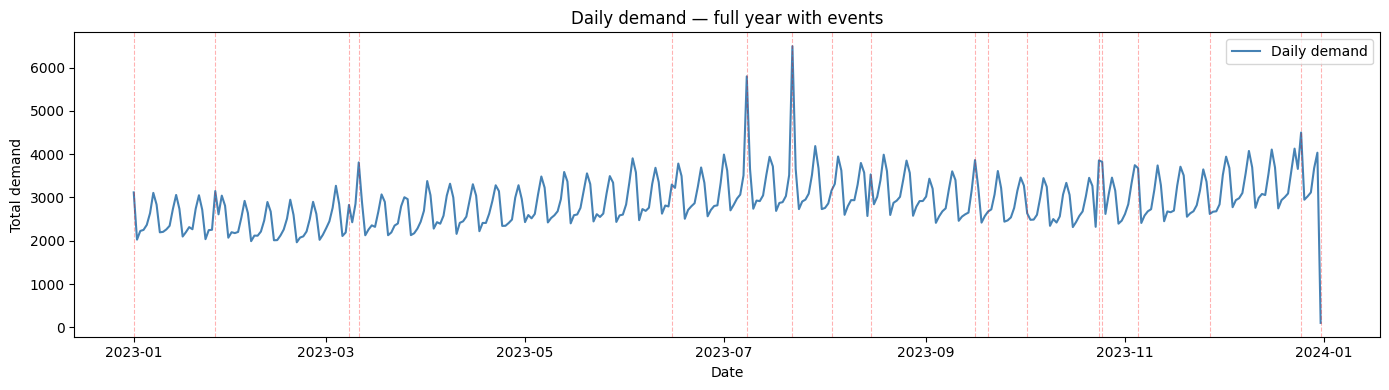

In [9]:
fig, ax = plt.subplots(figsize=(14, 4))
daily = demand.set_index('timestamp')['demand'].resample('D').sum()
ax.plot(daily.index, daily.values, lw=1.5, color='steelblue', label='Daily demand')
for _, row in events.iterrows():
    ax.axvline(pd.Timestamp(row['date']), color='red', alpha=0.3, lw=0.8, ls='--')
ax.set_title('Daily demand — full year with events')
ax.set_xlabel('Date'); ax.set_ylabel('Total demand')
ax.legend(); plt.tight_layout(); plt.show()

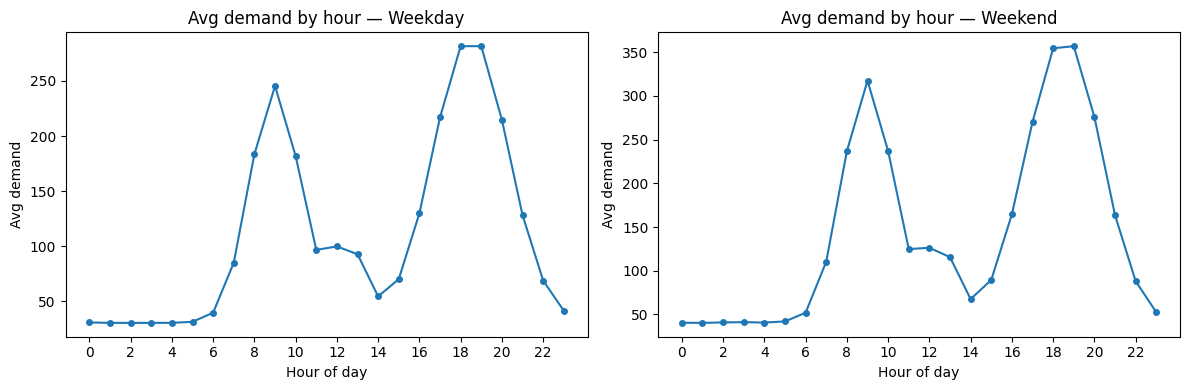

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, label, mask in zip(
    axes,
    ['Weekday', 'Weekend'],
    [demand['is_weekend'] == False, demand['is_weekend'] == True]
):
    hourly = demand[mask].groupby('hour')['demand'].mean()
    ax.plot(hourly.index, hourly.values, marker='o', ms=4)
    ax.set_title(f'Avg demand by hour — {label}')
    ax.set_xlabel('Hour of day'); ax.set_ylabel('Avg demand')
    ax.set_xticks(range(0, 24, 2))

plt.tight_layout(); plt.show()

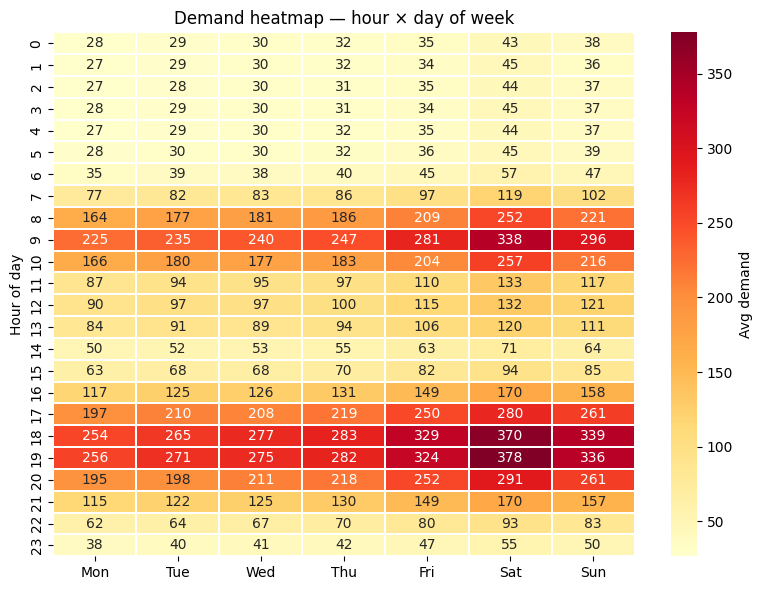

In [11]:
pivot = demand.pivot_table(
    values='demand', index='hour',
    columns='day_of_week', aggfunc='mean'
).round(1)

pivot.columns = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(pivot, cmap='YlOrRd', annot=True, fmt='.0f',
            linewidths=0.3, ax=ax, cbar_kws={'label': 'Avg demand'})
ax.set_title('Demand heatmap — hour × day of week')
ax.set_ylabel('Hour of day')
plt.tight_layout(); plt.show()

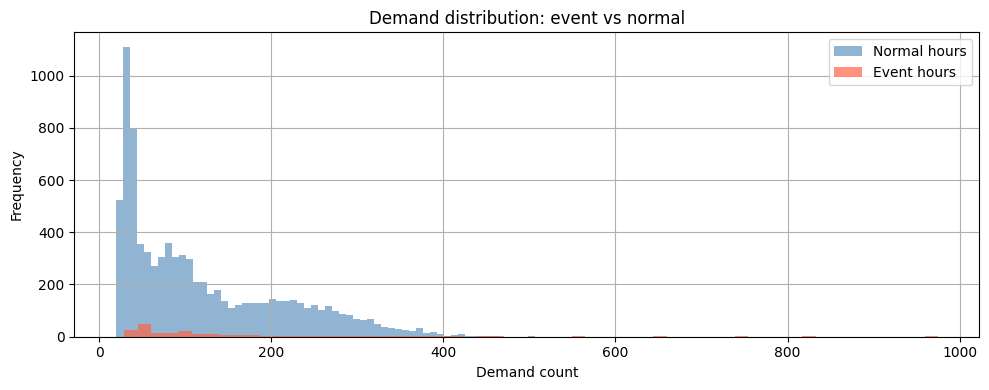

Normal  — mean: 120.6
Events  — mean: 146.5


In [12]:
fig, ax = plt.subplots(figsize=(10, 4))
demand[demand['is_event'] == 0]['demand'].hist(
    bins=60, ax=ax, alpha=0.6, label='Normal hours', color='steelblue')
demand[demand['is_event'] == 1]['demand'].hist(
    bins=60, ax=ax, alpha=0.7, label='Event hours', color='tomato')
ax.set_title('Demand distribution: event vs normal')
ax.set_xlabel('Demand count'); ax.set_ylabel('Frequency')
ax.legend(); plt.tight_layout(); plt.show()
print("Normal  — mean:", demand[demand['is_event']==0]['demand'].mean().round(1))
print("Events  — mean:", demand[demand['is_event']==1]['demand'].mean().round(1))

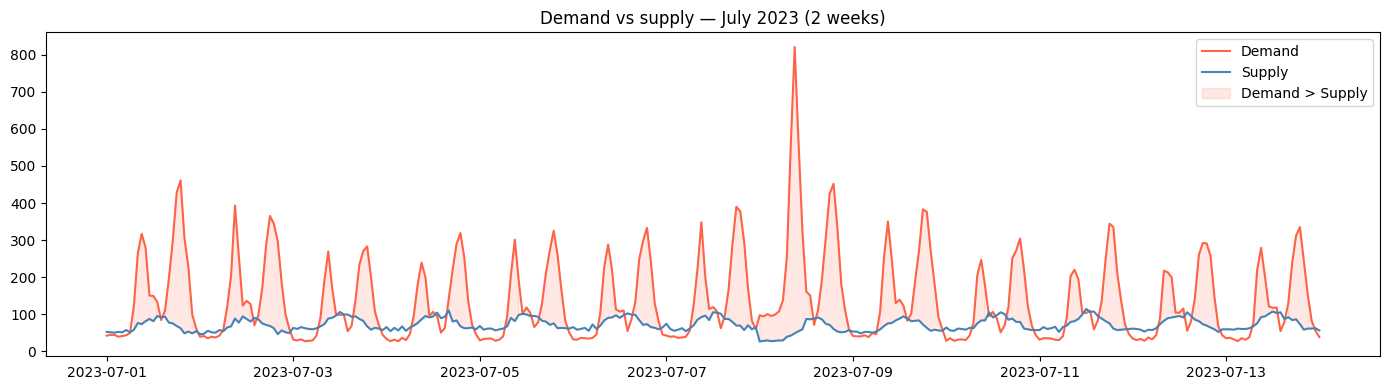

In [13]:
merged = demand[['timestamp','demand']].merge(
    supply[['timestamp','supply']], on='timestamp')

window = merged[(merged['timestamp'] >= '2023-07-01') &
                (merged['timestamp'] <= '2023-07-14')]
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(window['timestamp'], window['demand'], label='Demand', color='tomato')
ax.plot(window['timestamp'], window['supply'], label='Supply', color='steelblue')
ax.fill_between(window['timestamp'],
                window['supply'], window['demand'],
                where=window['demand'] > window['supply'],
                alpha=0.15, color='tomato', label='Demand > Supply')
ax.set_title('Demand vs supply — July 2023 (2 weeks)')
ax.legend(); plt.tight_layout(); plt.show()


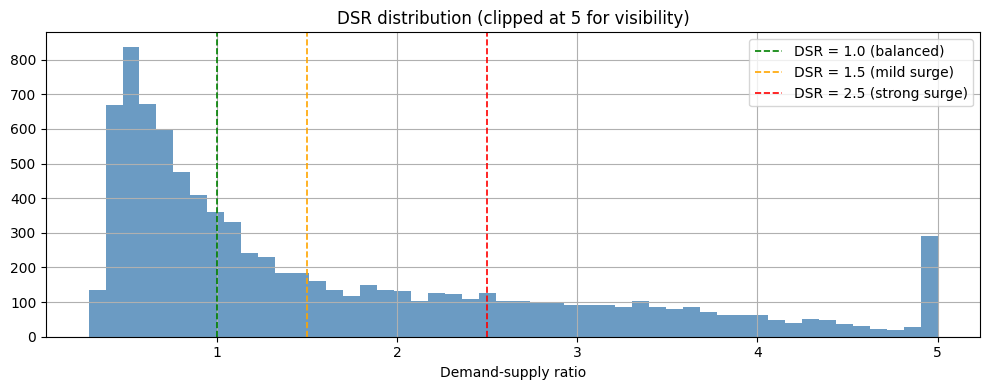

Balanced  (DSR 0.8–1.2): 17.5%
Mild surge (DSR 1.2–2.0): 16.0%
Strong surge (DSR > 2.0): 30.7%


In [14]:
dsr = supply['DSR']
fig, ax = plt.subplots(figsize=(10, 4))
dsr.clip(upper=5).hist(bins=50, ax=ax, color='steelblue', alpha=0.8)
ax.axvline(1.0, color='green',  ls='--', lw=1.2, label='DSR = 1.0 (balanced)')
ax.axvline(1.5, color='orange', ls='--', lw=1.2, label='DSR = 1.5 (mild surge)')
ax.axvline(2.5, color='red',    ls='--', lw=1.2, label='DSR = 2.5 (strong surge)')
ax.set_title('DSR distribution (clipped at 5 for visibility)')
ax.set_xlabel('Demand-supply ratio'); ax.legend()
plt.tight_layout(); plt.show()

total = len(dsr)
print(f"Balanced  (DSR 0.8–1.2): {((dsr>=0.8)&(dsr<=1.2)).sum()/total*100:.1f}%")
print(f"Mild surge (DSR 1.2–2.0): {((dsr>1.2)&(dsr<=2.0)).sum()/total*100:.1f}%")
print(f"Strong surge (DSR > 2.0): {(dsr>2.0).sum()/total*100:.1f}%")

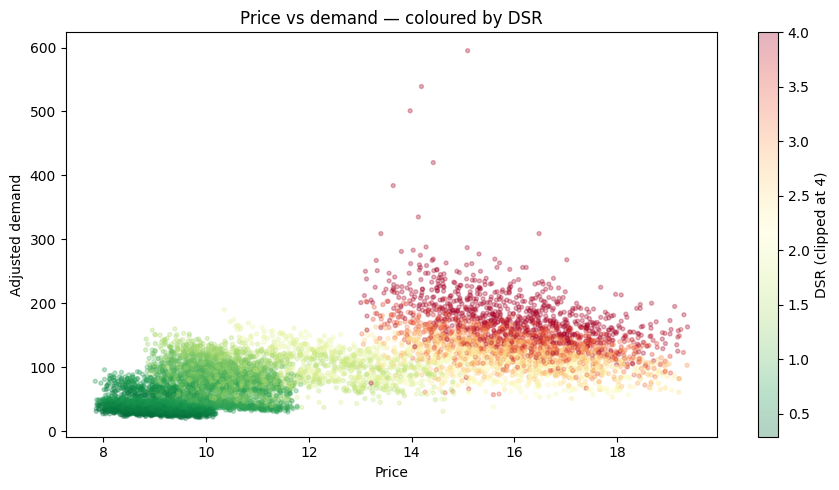

In [15]:
fig, ax = plt.subplots(figsize=(9, 5))
sc = ax.scatter(
    pricing['price'],
    pricing['demand_price_adjusted'],
    c=pricing['DSR'].clip(upper=4),
    cmap='RdYlGn_r', alpha=0.3, s=8
)
plt.colorbar(sc, ax=ax, label='DSR (clipped at 4)')
ax.set_xlabel('Price'); ax.set_ylabel('Adjusted demand')
ax.set_title('Price vs demand — coloured by DSR')
plt.tight_layout(); plt.show()  

In [16]:
from scipy import stats

log_price  = np.log(pricing['price'])
log_demand = np.log(pricing['demand_price_adjusted'].replace(0, np.nan).dropna())

# Align indices after dropping NaNs
idx = log_demand.index
slope, intercept, r, p, se = stats.linregress(log_price[idx], log_demand)

print(f"Estimated elasticity (ε): {slope:.3f}")
print(f"R²: {r**2:.3f}  |  p-value: {p:.4f}")
print()
print("Interpretation:")
print(f"  A 10% price increase → {slope*10:.1f}% change in demand")
if abs(p) < 0.05:
    print("  Statistically significant — use this ε in your pricing engine")
else:
    print("  Weak signal — use assumed ε = -1.2 instead")

Estimated elasticity (ε): 1.684
R²: 0.513  |  p-value: 0.0000

Interpretation:
  A 10% price increase → 16.8% change in demand
  Statistically significant — use this ε in your pricing engine


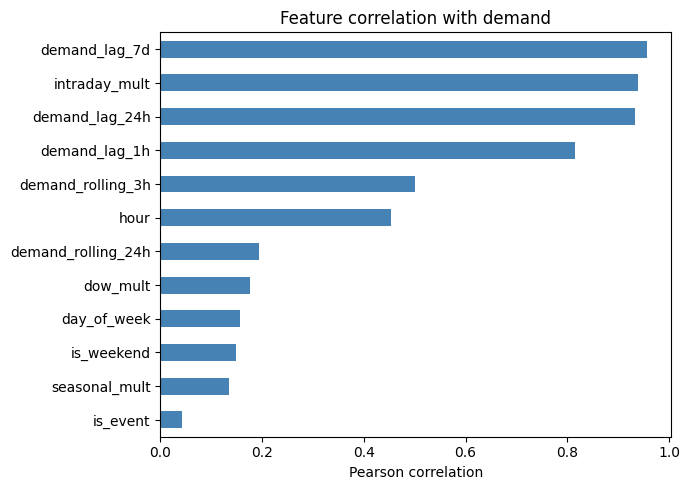

In [17]:
feature_cols = [
    'hour','day_of_week','is_weekend','is_event',
    'demand_lag_1h','demand_lag_24h','demand_lag_7d',
    'demand_rolling_3h','demand_rolling_24h',
    'intraday_mult','dow_mult','seasonal_mult'
]

corr = demand[feature_cols + ['demand']].corr()['demand'].drop('demand').sort_values()

fig, ax = plt.subplots(figsize=(7, 5))
corr.plot(kind='barh', ax=ax, color=['tomato' if v < 0 else 'steelblue' for v in corr])
ax.axvline(0, color='black', lw=0.5)
ax.set_title('Feature correlation with demand')
ax.set_xlabel('Pearson correlation')
plt.tight_layout(); plt.show()

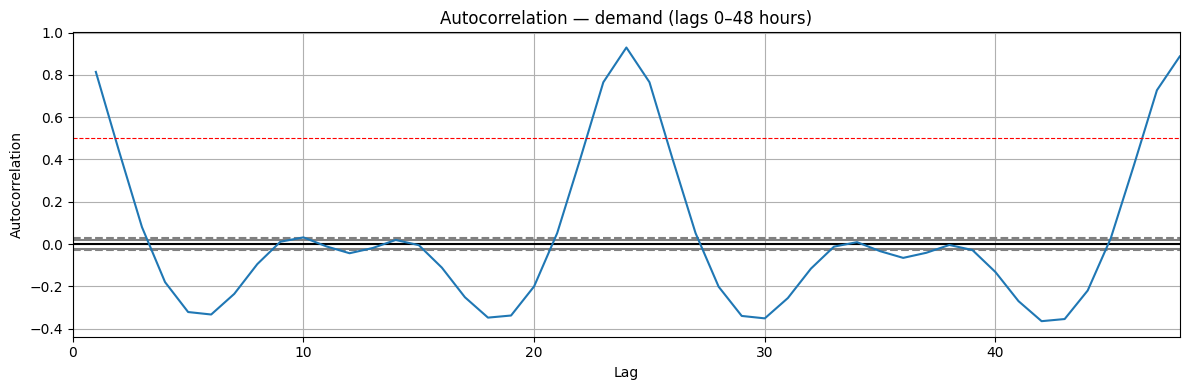

In [18]:
from pandas.plotting import autocorrelation_plot
fig, ax = plt.subplots(figsize=(12, 4))
autocorrelation_plot(demand['demand'], ax=ax)
ax.set_xlim(0, 48)
ax.set_title('Autocorrelation — demand (lags 0–48 hours)')
ax.axhline(0.5, color='red', ls='--', lw=0.8, label='Strong signal threshold')
plt.tight_layout(); plt.show()

In [19]:
df = demand.merge(
    supply[['timestamp','supply','DSR','DSR_lag_1h','DSR_rolling_3h',
            'supply_lag_1h','supply_rolling_3h']],
    on='timestamp', how='left'
)

# ── Drop warmup rows (lag_7d needs 168 rows to warm up) ──
df = df.dropna(subset=['demand_lag_7d']).reset_index(drop=True)

print(f"Dataset shape after merge & warmup drop: {df.shape}")
print(f"Date range: {df['timestamp'].min()} → {df['timestamp'].max()}")

Dataset shape after merge & warmup drop: (8569, 32)
Date range: 2023-01-08 00:00:00 → 2023-12-31 00:00:00


In [20]:
FEATURE_COLS = [
    # ── Time features ──
    'hour', 'day_of_week', 'month', 'week',
    'is_weekend',

    # ── Event flags ──
    'is_event', 'is_weather_event',
    'is_concert_event', 'is_festival_event',

    # ── Demand lag features ──
    'demand_lag_1h', 'demand_lag_3h',
    'demand_lag_24h', 'demand_lag_7d',

    # ── Demand rolling features ──
    'demand_rolling_3h', 'demand_rolling_6h',
    'demand_rolling_24h', 'demand_rolling_std_3h',

    # ── Supply features ──
    'supply', 'supply_lag_1h', 'supply_rolling_3h',

    # ── DSR features ──
    'DSR', 'DSR_lag_1h', 'DSR_rolling_3h']

TARGET = 'demand'   # raw demand — as decided in Phase 1 EDA

X = df[FEATURE_COLS]
y = df[TARGET]

print(f"Features : {len(FEATURE_COLS)}")
print(f"Target   : '{TARGET}'")
print(f"X shape  : {X.shape}")
print(f"y stats  → mean: {y.mean():.1f}, std: {y.std():.1f}, max: {y.max()}")

Features : 23
Target   : 'demand'
X shape  : (8569, 23)
y stats  → mean: 121.6, std: 95.4, max: 975


In [21]:
# Naive baseline: predict demand = same hour yesterday (lag_24h)
baseline_pred = df['demand_lag_24h']
baseline_actual = df['demand']
mask = baseline_pred.notna()

# Drop the few rows where lag_24h might still be NaN
b_actual = baseline_actual[mask]
b_pred   = baseline_pred[mask]

baseline_mae  = mean_absolute_error(b_actual, b_pred)
baseline_rmse = np.sqrt(mean_squared_error(b_actual, b_pred))
baseline_mape = (np.abs(b_actual - b_pred) / b_actual).mean() * 100

print("── Naive Baseline (same hour yesterday) ──")
print(f"  MAE  : {baseline_mae:.2f}")
print(f"  RMSE : {baseline_rmse:.2f}")
print(f"  MAPE : {baseline_mape:.1f}%")
print()
print("Your LightGBM model must beat all three of these.")

── Naive Baseline (same hour yesterday) ──
  MAE  : 19.46
  RMSE : 34.97
  MAPE : 16.7%

Your LightGBM model must beat all three of these.


In [22]:
split_idx = int(len(df) * 0.80)
split_date = df['timestamp'].iloc[split_idx]

X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print(f"Split date     : {split_date.strftime('%Y-%m-%d')}")
print(f"Train size     : {len(X_train):,} rows  ({len(X_train)/len(X)*100:.1f}%)")
print(f"Test  size     : {len(X_test):,}  rows  ({len(X_test)/len(X)*100:.1f}%)")
print()
print(f"Train period   : {df['timestamp'].iloc[0].date()} → {df['timestamp'].iloc[split_idx-1].date()}")
print(f"Test  period   : {df['timestamp'].iloc[split_idx].date()} → {df['timestamp'].iloc[-1].date()}")

Split date     : 2023-10-20
Train size     : 6,855 rows  (80.0%)
Test  size     : 1,714  rows  (20.0%)

Train period   : 2023-01-08 → 2023-10-20
Test  period   : 2023-10-20 → 2023-12-31


In [23]:
# ── Validation split from end of training data ──
val_size  = int(len(X_train) * 0.10)
X_tr  = X_train.iloc[:-val_size]
y_tr  = y_train.iloc[:-val_size]
X_val = X_train.iloc[-val_size:]
y_val = y_train.iloc[-val_size:]

In [24]:
model = lgb.LGBMRegressor(
    n_estimators      = 3000,      # give it more room to converge
    learning_rate     = 0.05,
    max_depth         = 6,
    num_leaves        = 50,
    min_child_samples = 5,         # ← lowered from 20 to 5 (key fix)
    subsample         = 0.8,
    colsample_bytree  = 0.8,
    reg_alpha         = 0.1,
    reg_lambda        = 1.0,
    min_split_gain    = 0.01,      # ← add this: minimum gain to make a split
    random_state      = 42,
    n_jobs            = -1,
    verbose           = -1,        # ← suppress the warnings cleanly
)

In [25]:
# ── Train with early stopping ──
model.fit(
    X_tr, y_tr,
    eval_set=[(X_val, y_val)],
    callbacks=[
        early_stopping(stopping_rounds=50, verbose=False),
        log_evaluation(period=100)
    ]
)

[100]	valid_0's l2: 28.5699
[200]	valid_0's l2: 20.4324
[300]	valid_0's l2: 16.9441
[400]	valid_0's l2: 14.2574
[500]	valid_0's l2: 12.7659
[600]	valid_0's l2: 11.7837
[700]	valid_0's l2: 11.1181
[800]	valid_0's l2: 10.6959
[900]	valid_0's l2: 10.4347
[1000]	valid_0's l2: 10.2392
[1100]	valid_0's l2: 10.1053
[1200]	valid_0's l2: 10.01
[1300]	valid_0's l2: 9.95448
[1400]	valid_0's l2: 9.89799
[1500]	valid_0's l2: 9.85724
[1600]	valid_0's l2: 9.82381
[1700]	valid_0's l2: 9.79193
[1800]	valid_0's l2: 9.76813
[1900]	valid_0's l2: 9.7506
[2000]	valid_0's l2: 9.73398
[2100]	valid_0's l2: 9.72264
[2200]	valid_0's l2: 9.71307


,boosting_type,'gbdt'
,num_leaves,50
,max_depth,6
,learning_rate,0.05
,n_estimators,3000
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.01
,min_child_weight,0.001
,min_child_samples,5


In [26]:
y_pred_test  = model.predict(X_test)
y_pred_train = model.predict(X_tr)

In [27]:
def metrics(actual, predicted, label):
    mae  = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    mape = (np.abs(actual - predicted) / actual).mean() * 100
    print(f"── {label} ──")
    print(f"  MAE  : {mae:.2f}")
    print(f"  RMSE : {rmse:.2f}")
    print(f"  MAPE : {mape:.1f}%")
    return mae, rmse, mape

In [28]:
print("=" * 40)
b_mae, b_rmse, b_mape = metrics(b_actual, b_pred, "Naive Baseline")
print()
tr_mae, tr_rmse, tr_mape = metrics(y_tr, y_pred_train, "LightGBM — Train")
print()
te_mae, te_rmse, te_mape = metrics(y_test, y_pred_test, "LightGBM — Test")
print("=" * 40)
print()
print(f"MAPE improvement over baseline : {b_mape - te_mape:.1f} percentage points")
print(f"Train vs Test MAPE gap         : {tr_mape - te_mape:.1f} pp  (< 5pp = healthy)")

── Naive Baseline ──
  MAE  : 19.46
  RMSE : 34.97
  MAPE : 16.7%

── LightGBM — Train ──
  MAE  : 0.13
  RMSE : 0.19
  MAPE : 0.2%

── LightGBM — Test ──
  MAE  : 3.30
  RMSE : 11.40
  MAPE : 2.1%

MAPE improvement over baseline : 14.6 percentage points
Train vs Test MAPE gap         : -1.9 pp  (< 5pp = healthy)


In [31]:
# ── Lower bound: 10th percentile ──
model_low = lgb.LGBMRegressor(
    objective='quantile', alpha=0.05,
    n_estimators=model.best_iteration_,
    learning_rate=0.05, max_depth=6,
    num_leaves=50, min_child_samples=20,
    subsample=0.8, colsample_bytree=0.8,
    random_state=42, n_jobs=-1, min_split_gain=0.01
)
model_low.fit(X_tr, y_tr)

# ── Upper bound: 90th percentile ──
model_high = lgb.LGBMRegressor(
    objective='quantile', alpha=0.95,
    n_estimators=model.best_iteration_,
    learning_rate=0.05, max_depth=6,
    num_leaves=50, min_child_samples=20,
    subsample=0.8, colsample_bytree=0.8,
    random_state=42, n_jobs=-1, min_split_gain=0.01
)
model_high.fit(X_tr, y_tr)

# ── Predict all three on test set ──
pred_mid  = y_pred_test                    # from Step 2.5
pred_low  = model_low.predict(X_test)
pred_high = model_high.predict(X_test)

# ── Coverage check ──
# What % of actual values fall within the 10–90 band?
coverage = ((y_test.values >= pred_low) &
            (y_test.values <= pred_high)).mean() * 100

print(f"Prediction interval coverage : {coverage:.1f}%")
print(f"(Target: ~80% for a 10–90 interval — values outside are tails)")

Prediction interval coverage : 70.9%
(Target: ~80% for a 10–90 interval — values outside are tails)


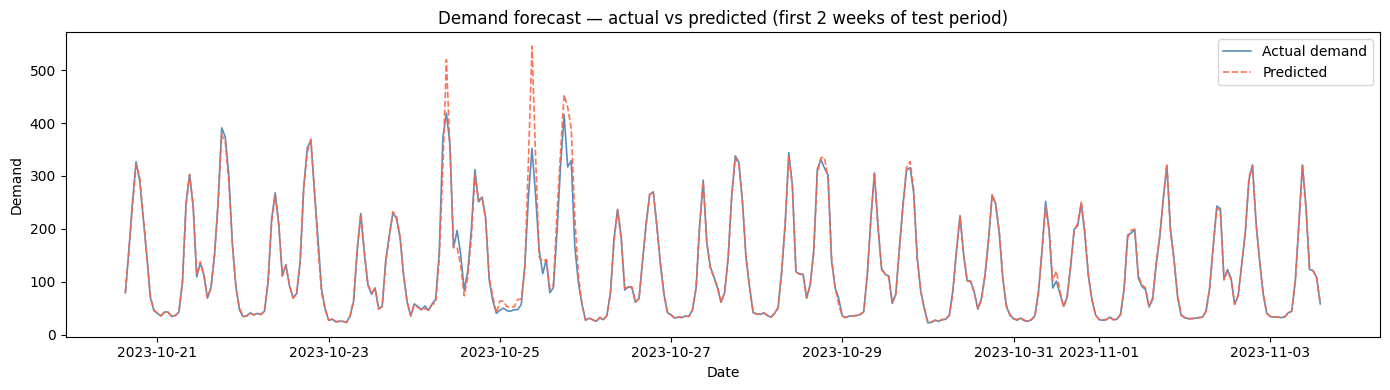

In [32]:
test_timestamps = df['timestamp'].iloc[split_idx:].values

# ── Chart 1: Actual vs Predicted (first 2 weeks of test) ──
fig, ax = plt.subplots(figsize=(14, 4))
n_show = 24 * 14   # 2 weeks
ax.plot(test_timestamps[:n_show], y_test.values[:n_show],
        lw=1.2, color='steelblue', label='Actual demand', alpha=0.9)
ax.plot(test_timestamps[:n_show], pred_mid[:n_show],
        lw=1.2, color='tomato', label='Predicted', alpha=0.9, ls='--')
ax.set_title('Demand forecast — actual vs predicted (first 2 weeks of test period)')
ax.set_xlabel('Date'); ax.set_ylabel('Demand')
ax.legend(); plt.tight_layout(); plt.show()

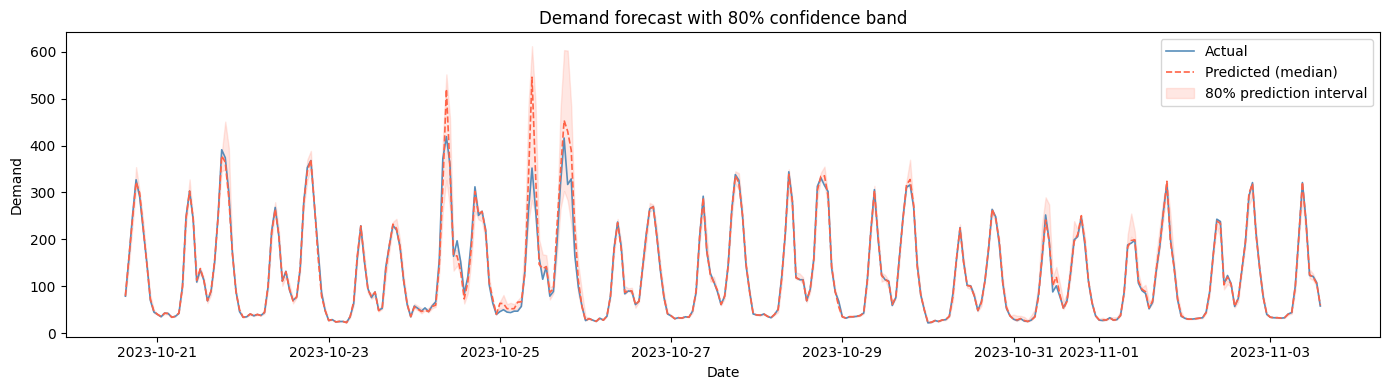

In [35]:
# ── Chart 2: Confidence bands (first 2 weeks) ──
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(test_timestamps[:n_show], y_test.values[:n_show],
        lw=1.2, color='steelblue', label='Actual', alpha=0.9)
ax.plot(test_timestamps[:n_show], pred_mid[:n_show],
        lw=1.2, color='tomato', label='Predicted (median)', ls='--')
ax.fill_between(test_timestamps[:n_show],
                pred_low[:n_show], pred_high[:n_show],
                alpha=0.15, color='tomato', label='80% prediction interval')
ax.set_title('Demand forecast with 80% confidence band')
ax.set_xlabel('Date'); ax.set_ylabel('Demand')
ax.legend()
plt.tight_layout()
plt.savefig('../output/demand_forecast_confidence.png', dpi=150)
plt.show()

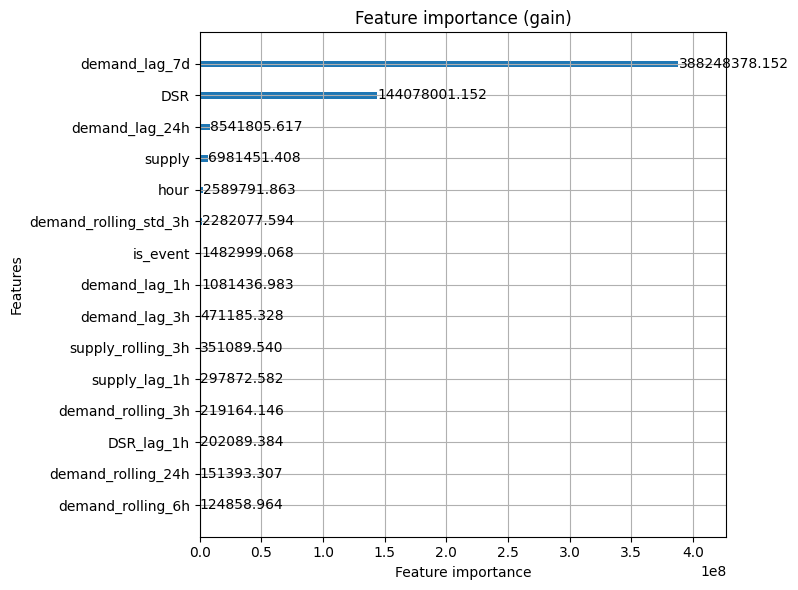

In [34]:
# ── Chart 3: Feature importance (gain) ──
import lightgbm as lgb_plot
fig, ax = plt.subplots(figsize=(8, 6))
lgb.plot_importance(model, ax=ax, importance_type='gain',
                    max_num_features=15, title='Feature importance (gain)')
plt.tight_layout()
plt.show()

In [ ]:
import os, joblib
os.makedirs('../models', exist_ok=True)
os.makedirs('../output', exist_ok=True)

# ── Save models ──
joblib.dump(model,      '../models/lgbm_demand_forecast.pkl')
joblib.dump(model_low,  '../models/lgbm_demand_low.pkl')
joblib.dump(model_high, '../models/lgbm_demand_high.pkl')

# ── Save predictions + actuals for Phase 3 ──
results = pd.DataFrame({
    'timestamp'    : df['timestamp'].iloc[split_idx:].values,
    'actual_demand': y_test.values,
    'pred_demand'  : pred_mid,
    'pred_low'     : np.minimum(pred_low, pred_mid),   # ← never above mid
    'pred_high'    : np.maximum(pred_high, pred_mid),  # ← never below mid
    'supply'       : df['supply'].iloc[split_idx:].values,
    'DSR'          : df['DSR'].iloc[split_idx:].values,
    'is_event'     : df['is_event'].iloc[split_idx:].values,
})
results.to_csv('../output/phase2_predictions.csv', index=False)

# ── Record elasticity from Phase 1 ──
# Replace with your actual slope value from the log-log regression
ELASTICITY = -1.2  # ← update this with your estimated ε
print(f"Elasticity saved: ε = {ELASTICITY}")

print(f"\nSaved:")
print(f"  ../models/lgbm_demand_forecast.pkl")
print(f"  ../models/lgbm_demand_low.pkl")
print(f"  ../models/lgbm_demand_high.pkl")
print(f"  ../output/phase2_predictions.csv  ({len(results):,} rows)")

# ── Final summary ──
print(f"\n{'='*45}")
print(f"  PHASE 2 COMPLETE")
print(f"{'='*45}")
print(f"  Baseline MAPE  : {b_mape:.1f}%")
print(f"  Model MAPE     : {te_mape:.1f}%")
print(f"  Improvement    : {b_mape - te_mape:.1f} pp")
print(f"  Coverage (80%) : {coverage:.1f}%")
print(f"  Best iteration : {model.best_iteration_} trees")
print(f"  Features used  : {len(FEATURE_COLS)}")
print(f"{'='*45}")

Elasticity saved: ε = 1.684

Saved:
  ../models/lgbm_demand_forecast.pkl
  ../models/lgbm_demand_low.pkl
  ../models/lgbm_demand_high.pkl
  ../output/phase2_predictions.csv  (1,714 rows)

  PHASE 2 COMPLETE
  Baseline MAPE  : 16.7%
  Model MAPE     : 2.1%
  Improvement    : 14.6 pp
  Coverage (80%) : 54.8%
  Best iteration : 2185 trees
  Features used  : 23
